In [ ]:
import json
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

In [ ]:
# Load the network JSON
with open('../data/Emails_Graph_kmeans.json', 'r') as f:
    data = json.load(f)

# Build networkx graph
G = nx.Graph()
for node in data['nodes']:
    G.add_node(node['id'], community=node['community'],
               cluster_label=node['cluster_label'], degree=node['degree'])
for link in data['links']:
    G.add_edge(link['source'], link['target'])

# Index metadata for quick lookup
node_meta = {n['id']: n for n in data['nodes']}

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")
print(f"Clusters: {sorted(set(n['cluster_label'] for n in data['nodes']))}")

Nodes: 153  |  Edges: 984
Clusters: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [3]:
# Color palette — one hex color per k-means cluster (0–9)
CLUSTER_COLORS = {
    '0': '#e6194b',  # red
    '1': '#3cb44b',  # green
    '2': '#4363d8',  # blue
    '3': '#f58231',  # orange
    '4': '#911eb4',  # purple
    '5': '#42d4f4',  # cyan
    '6': '#f032e6',  # magenta
    '7': '#bfef45',  # lime
    '8': '#fabed4',  # pink
    '9': '#469990',  # teal
}

In [ ]:
# ── Prepare data for D3.js ─────────────────────────────────────────────────
d3_nodes = [
    {
        'id':      n['id'],
        'cluster': str(n['cluster_label']),
        'degree':  n['degree']
    }
    for n in data['nodes']
]

d3_links = [
    {'source': lnk['source'], 'target': lnk['target']}
    for lnk in data['links']
]

nodes_json  = json.dumps(d3_nodes)
links_json  = json.dumps(d3_links)
colors_json = json.dumps(CLUSTER_COLORS)

html = f"""
<div id="net-container"
     style="width:100%;display:flex;justify-content:center;align-items:center;
            background:#1a1a2e;border-radius:12px;overflow:hidden;">
  <svg id="net-svg"></svg>
</div>

<style>
  #net-svg {{ display:block; }}

  .link        {{ stroke:rgba(255,255,255,0.15); stroke-width:0.8px; }}
  .link.dimmed {{ opacity:0.04; }}

  .node circle {{ cursor:pointer; stroke:rgba(255,255,255,0.55); stroke-width:1px; }}
  .node text   {{ pointer-events:none; fill:#fff; text-anchor:middle;
                  dominant-baseline:central; font-family:system-ui,sans-serif; }}

  /* dimmed  → nearly invisible */
  .node.dimmed circle {{ opacity:0.08; }}
  .node.dimmed text   {{ opacity:0.04; }}

  /* highlighted → bright border + slight glow */
  .node.highlighted circle {{
    stroke:#fff; stroke-width:3px;
    filter:drop-shadow(0 0 4px currentColor);
  }}
</style>

<script src="https://d3js.org/d3.v7.min.js"></script>
<script>
(function () {{
  const nodes  = {nodes_json};
  const links  = {links_json};
  const COLORS = {colors_json};

  const W = 1400, H = 860;

  /* ── SVG + viewBox (centered) ──────────────────────────────────── */
  const svg = d3.select('#net-svg')
    .attr('viewBox', `0 0 ${{W}} ${{H}}`)
    .attr('width',  '100%')
    .attr('height',  H)
    .attr('overflow', 'hidden')
    .style('max-width', '100%');

  /* ── Zoom / Pan ────────────────────────────────────────────────── */
  const g = svg.append('g');
  svg.call(
    d3.zoom()
      .scaleExtent([0.1, 10])
      .on('zoom', e => g.attr('transform', e.transform))
  );

  /* ── Size scale  (sqrt → area ∝ degree) ───────────────────────── */
  const [degMin, degMax] = d3.extent(nodes, d => d.degree);
  const rScale = d3.scaleSqrt().domain([degMin, degMax]).range([5, 28]);

  /* ── Pre-initialize nodes near center ─────────────────────────── */
  nodes.forEach(d => {{ d.x = W / 2 + (Math.random() - 0.5) * 200;
                         d.y = H / 2 + (Math.random() - 0.5) * 200; }});

  /* ── Force simulation ──────────────────────────────────────────── */
  const sim = d3.forceSimulation(nodes)
    .force('link',    d3.forceLink(links).id(d => d.id).distance(35))
    .force('charge',  d3.forceManyBody().strength(-120))
    .force('center',  d3.forceCenter(W / 2, H / 2))
    .force('x',       d3.forceX(W / 2).strength(0.08))
    .force('y',       d3.forceY(H / 2).strength(0.08))
    .force('collide', d3.forceCollide().radius(d => rScale(d.degree) + 4));

  /* ── Links ─────────────────────────────────────────────────────── */
  const linkSel = g.append('g')
    .selectAll('line')
    .data(links)
    .join('line')
    .attr('class', 'link');

  /* ── Nodes ─────────────────────────────────────────────────────── */
  const nodeSel = g.append('g')
    .selectAll('g')
    .data(nodes)
    .join('g')
    .attr('class', 'node')
    .call(
      d3.drag()
        .on('start', (e, d) => {{ if (!e.active) sim.alphaTarget(0.3).restart(); d.fx = d.x; d.fy = d.y; }})
        .on('drag',  (e, d) => {{ d.fx = e.x; d.fy = e.y; }})
        .on('end',   (e, d) => {{ if (!e.active) sim.alphaTarget(0); d.fx = null; d.fy = null; }})
    );

  /* circle colored by cluster */
  nodeSel.append('circle')
    .attr('r',    d => rScale(d.degree))
    .attr('fill', d => COLORS[d.cluster] || '#aaaaaa');

  /* label — font-size proportional to node radius */
  nodeSel.append('text')
    .style('font-size', d => `${{Math.max(6, rScale(d.degree) * 0.65)}}px`)
    .text(d => d.id.split('@')[0]);

  /* ── Hover: highlight same-cluster, dim the rest ───────────────── */
  nodeSel
    .on('mouseover', function (event, d) {{
      const c = d.cluster;
      nodeSel
        .classed('dimmed',      n => n.cluster !== c)
        .classed('highlighted', n => n.cluster === c);
      linkSel.classed('dimmed', l =>
        l.source.cluster !== c || l.target.cluster !== c
      );
    }})
    .on('mouseout', function () {{
      nodeSel.classed('dimmed',      false)
             .classed('highlighted', false);
      linkSel.classed('dimmed', false);
    }});

  /* ── Tick ──────────────────────────────────────────────────────── */
  sim.on('tick', () => {{
    linkSel
      .attr('x1', d => d.source.x).attr('y1', d => d.source.y)
      .attr('x2', d => d.target.x).attr('y2', d => d.target.y);
    nodeSel.attr('transform', d => {{
      const r = rScale(d.degree);
      d.x = Math.max(r, Math.min(W - r, d.x));
      d.y = Math.max(r, Math.min(H - r, d.y));
      return `translate(${{d.x}},${{d.y}})`;
    }});
  }});
}})();
</script>
"""

display(HTML(html))
print("D3.js network rendered.")

In [ ]:
# Save the visualization to an HTML file
from pathlib import Path

output = Path('network.html')
output.write_text(html)
print(f"Saved → {output.resolve()}")

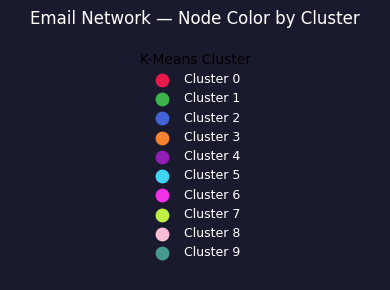

In [5]:
# Static legend — cluster label → color
fig, ax = plt.subplots(figsize=(4, 3), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')
for label, color in sorted(CLUSTER_COLORS.items(), key=lambda x: int(x[0])):
    ax.scatter([], [], c=color, label=f'Cluster {label}', s=80)
ax.legend(title='K-Means Cluster', loc='center', frameon=False,
          labelcolor='white', title_fontsize=10, fontsize=9,
          facecolor='#1a1a2e')
ax.axis('off')
ax.set_title('Email Network — Node Color by Cluster', color='white')
plt.tight_layout()
plt.show()